In [ ]:
!pip install requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time

In [ ]:
# Indicators of interest (indicator code: column name)
indicators = {
    "SH.IMM.MEAS": "Measles Immunization Rate(%)",
    "SH.IMM.IDPT": "dpt Immunization Rate(%)",
    "SH.IMM.POL3": "Polio Immunization Rate(%)",
    "SH.XPD.CHEX.PC.CD": "Health Expenditure per capita",
    "SP.DYN.IMRT.IN": "Infant Mortality Rate (per 1,000 live births)",
    "SP.DYN.LE00.IN": "life Expectancy"
}

# Define the year range
year_range = "2000:2024"

# Function to retrieve data for indicators
def fetch_indicator_data(indicator_code, column_name):
    url = f"http://api.worldbank.org/v2/country/all/indicator/{indicator_code}?format=json&per_page=20000&date={year_range}"
    response = requests.get(url)
    data = response.json()

    if response.status_code == 200 and data[1]:
        records = data[1]
        df = pd.DataFrame([
            {
                "Country": record["country"]["value"],
                "Year": int(record["date"]),
                column_name: record["value"]
            }
            for record in records if record["value"] is not None
        ])
        return df
    else:
        print(f"Failed to fetch {column_name}")
        return pd.DataFrame()

# Fetch and merge all indicators
final_df = None

for code, col_name in indicators.items():
    print(f"Fetching: {col_name}...")
    df = fetch_indicator_data(code, col_name)
    if final_df is None:
        final_df = df
    else:
        final_df = pd.merge(final_df, df, on=["Country", "Year"], how="outer")
    time.sleep(1)  # Pause to avoid rate-limiting

# Sort and display
if final_df is not None:
    final_df = final_df.sort_values(by=["Year", "Country"]).reset_index(drop=True)
    print(final_df.head())
else:
    print("No data was retrieved.")



Fetching: Measles Immunization Rate(%)...
Fetching: dpt Immunization Rate(%)...
Fetching: Polio Immunization Rate(%)...
Fetching: Health Expenditure per capita...
Fetching: Infant Mortality Rate (per 1,000 live births)...
Fetching: life Expectancy...
                       Country  Year  Measles Immunization Rate(%)  \
0                  Afghanistan  2000                     27.000000   
1  Africa Eastern and Southern  2000                     57.570201   
2   Africa Western and Central  2000                     44.489415   
3                      Albania  2000                     95.000000   
4                      Algeria  2000                     80.000000   

   dpt Immunization Rate(%)  Polio Immunization Rate(%)  \
0                 24.000000                   24.000000   
1                 56.871893                   59.953604   
2                 43.128074                   44.538924   
3                 97.000000                   97.000000   
4                 86.000000      

In [ ]:
final_df.head(10)


,Country,Year,Measles Immunization Rate(%),dpt Immunization Rate(%),Polio Immunization Rate(%),Health Expenditure per capita,"Infant Mortality Rate (per 1,000 live births)",life Expectancy
0,Afghanistan,2000,27.000000,24.000000,24.000000,NaN,92.000000,55.298000
1,Africa Eastern and Southern,2000,57.570201,56.871893,59.953604,43.015806,85.558918,51.986989
2,Africa Western and Central,2000,44.489415,43.128074,44.538924,19.989840,99.003498,50.194595
3,Albania,2000,95.000000,97.000000,97.000000,65.150124,24.000000,75.404000
4,Algeria,2000,80.000000,86.000000,86.000000,62.117695,35.600000,70.478000
5,Andorra,2000,97.000000,98.000000,95.000000,1287.002808,6.500000,NaN
6,Angola,2000,32.000000,31.000000,21.000000,13.000087,120.700000,46.024000
7,Antigua and Barbuda,2000,95.000000,95.000000,96.000000,519.131165,12.200000,74.606000
8,Arab World,2000,81.364852,82.843701,83.604665,105.295413,43.706068,67.148595
9,Argentina,2000,91.000000,83.000000,88.000000,704.945923,17.300000,73.926000


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6263 entries, 0 to 6262
Data columns (total 8 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Country                                        6263 non-null   object 
 1   Year                                           6263 non-null   int64  
 2   Measles Immunization Rate(%)                   5765 non-null   float64
 3   dpt Immunization Rate(%)                       5765 non-null   float64
 4   Polio Immunization Rate(%)                     5669 non-null   float64
 5   Health Expenditure per capita                  5166 non-null   float64
 6   Infant Mortality Rate (per 1,000 live births)  5612 non-null   float64
 7   life Expectancy                                5932 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 391.6+ KB


# **DATA PREPROCESSING**

In [ ]:
# Convert Infant Mortality Rate (per 1,000 live births) to percentage
final_df["Infant Mortality Rate (%)"] = final_df["Infant Mortality Rate (per 1,000 live births)"] / 10

# Convert year to timestamp (January 1st of that year)
final_df['Year'] = pd.to_datetime(final_df['Year'], format='%Y')

final_df

,Country,Year,Measles Immunization Rate(%),dpt Immunization Rate(%),Polio Immunization Rate(%),Health Expenditure per capita,"Infant Mortality Rate (per 1,000 live births)",life Expectancy,Infant Mortality Rate (%)
0,Afghanistan,2000-01-01,27.000000,24.000000,24.000000,NaN,92.000000,55.298000,9.200000
1,Africa Eastern and Southern,2000-01-01,57.570201,56.871893,59.953604,43.015806,85.558918,51.986989,8.555892
2,Africa Western and Central,2000-01-01,44.489415,43.128074,44.538924,19.989840,99.003498,50.194595,9.900350
3,Albania,2000-01-01,95.000000,97.000000,97.000000,65.150124,24.000000,75.404000,2.400000
4,Algeria,2000-01-01,80.000000,86.000000,86.000000,62.117695,35.600000,70.478000,3.560000
...,...,...,...,...,...,...,...,...,...
6258,West Bank and Gaza,2023-01-01,89.000000,88.000000,89.000000,NaN,NaN,NaN,NaN
6259,World,2023-01-01,83.128427,84.053782,83.544974,NaN,NaN,NaN,NaN
6260,"Yemen, Rep.",2023-01-01,45.000000,46.000000,46.000000,NaN,NaN,NaN,NaN
6261,Zambia,2023-01-01,90.000000,80.000000,81.000000,NaN,NaN,NaN,NaN


In [ ]:
# Dropping two unwanted columns ('Health Expenditure per capita' and 'life Expectancy')
final_df = final_df.drop(columns=['Health Expenditure per capita', 'life Expectancy', 'Infant Mortality Rate (per 1,000 live births)'])

# Drop rows with any NaN values
final_df = final_df.dropna()

# Round all float columns to 2 decimal places
final_df = final_df.round(0)

# Preview the cleaned DataFrame
final_df.head()


,Country,Year,Measles Immunization Rate(%),dpt Immunization Rate(%),Polio Immunization Rate(%),Infant Mortality Rate (%)
0,Afghanistan,2000-01-01,27.0,24.0,24.0,9.0
1,Africa Eastern and Southern,2000-01-01,58.0,57.0,60.0,9.0
2,Africa Western and Central,2000-01-01,44.0,43.0,45.0,10.0
3,Albania,2000-01-01,95.0,97.0,97.0,2.0
4,Algeria,2000-01-01,80.0,86.0,86.0,4.0


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5432 entries, 0 to 6021
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Country                       5432 non-null   object        
 1   Year                          5432 non-null   datetime64[ns]
 2   Measles Immunization Rate(%)  5432 non-null   float64       
 3   dpt Immunization Rate(%)      5432 non-null   float64       
 4   Polio Immunization Rate(%)    5432 non-null   float64       
 5   Infant Mortality Rate (%)     5432 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 297.1+ KB


**Save Cleaned Data into csv**

In [ ]:
# final_df.to_csv("world_bank_vaccination_health_data.csv", index=False)


# **EXPLORATORY DATA ANALYSIS**

In [ ]:
# Convert back to Year
final_df['Year'] = final_df['Year'].dt.year


In [ ]:
# Summary for numeric columns
final_df.describe()


,Year,Measles Immunization Rate(%),dpt Immunization Rate(%),Polio Immunization Rate(%),Infant Mortality Rate (%)
count,5432.000000,5432.000000,5432.000000,5432.000000,5432.00000
mean,2011.025405,85.248711,86.188144,86.188697,2.77743
std,6.629064,14.586670,14.291554,14.052061,2.51784
min,2000.000000,8.000000,0.000000,0.000000,0.00000
25%,2005.000000,79.000000,81.000000,80.000000,1.00000
50%,2011.000000,91.000000,92.000000,92.000000,2.00000
75%,2017.000000,96.000000,96.000000,96.000000,4.00000
max,2022.000000,99.000000,99.000000,99.000000,14.00000


**Correlation Analysis**

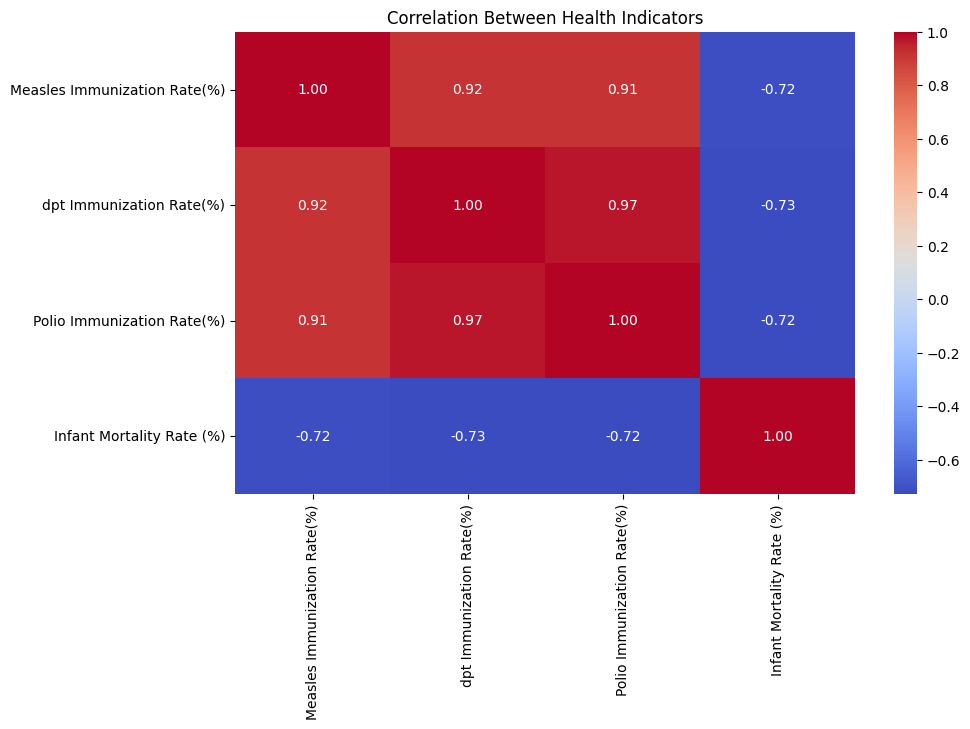

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(final_df.drop(columns=['Country', 'Year']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Health Indicators")
plt.show()


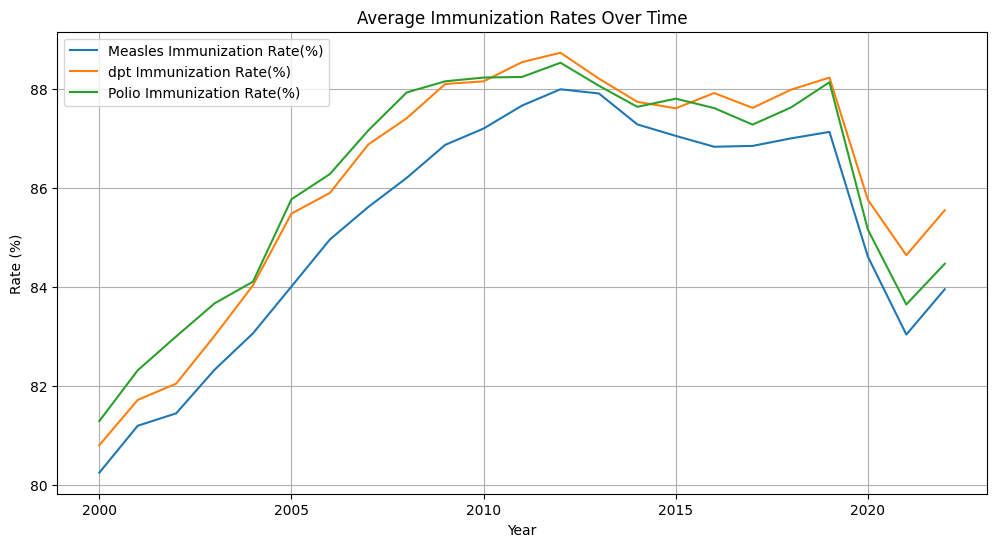

In [ ]:
# Average vaccination rates over years
plt.figure(figsize=(12,6))
for col in ['Measles Immunization Rate(%)', 'dpt Immunization Rate(%)', 'Polio Immunization Rate(%)']:
    final_df.groupby('Year')[col].mean().plot(label=col)

plt.legend()
plt.title("Average Immunization Rates Over Time")
plt.ylabel("Rate (%)")
plt.xlabel("Year")
plt.grid(True)
plt.show()


In [ ]:
final_df.head()

,Country,Year,Measles Immunization Rate(%),dpt Immunization Rate(%),Polio Immunization Rate(%),Infant Mortality Rate (%)
0,Afghanistan,2000,27.0,24.0,24.0,9.0
1,Africa Eastern and Southern,2000,58.0,57.0,60.0,9.0
2,Africa Western and Central,2000,44.0,43.0,45.0,10.0
3,Albania,2000,95.0,97.0,97.0,2.0
4,Algeria,2000,80.0,86.0,86.0,4.0


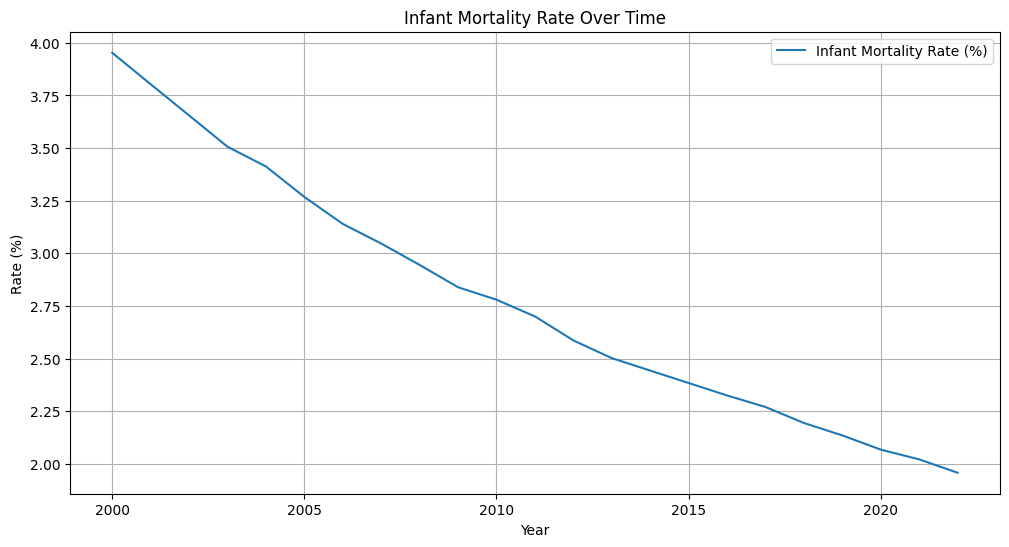

In [ ]:
# Average vaccination rates over years
plt.figure(figsize=(12,6))
for col in ["Infant Mortality Rate (%)"]:
    final_df.groupby('Year')[col].mean().plot(label=col)

plt.legend()
plt.title("Infant Mortality Rate Over Time")
plt.ylabel("Rate (%)")
plt.xlabel("Year")
plt.grid(True)
plt.show()

**Top Infant Mortality Rate By Countries**

<ipython-input-14-ade1fffb3fcf>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20_mortality.values, y=top20_mortality.index, palette="Reds_r")


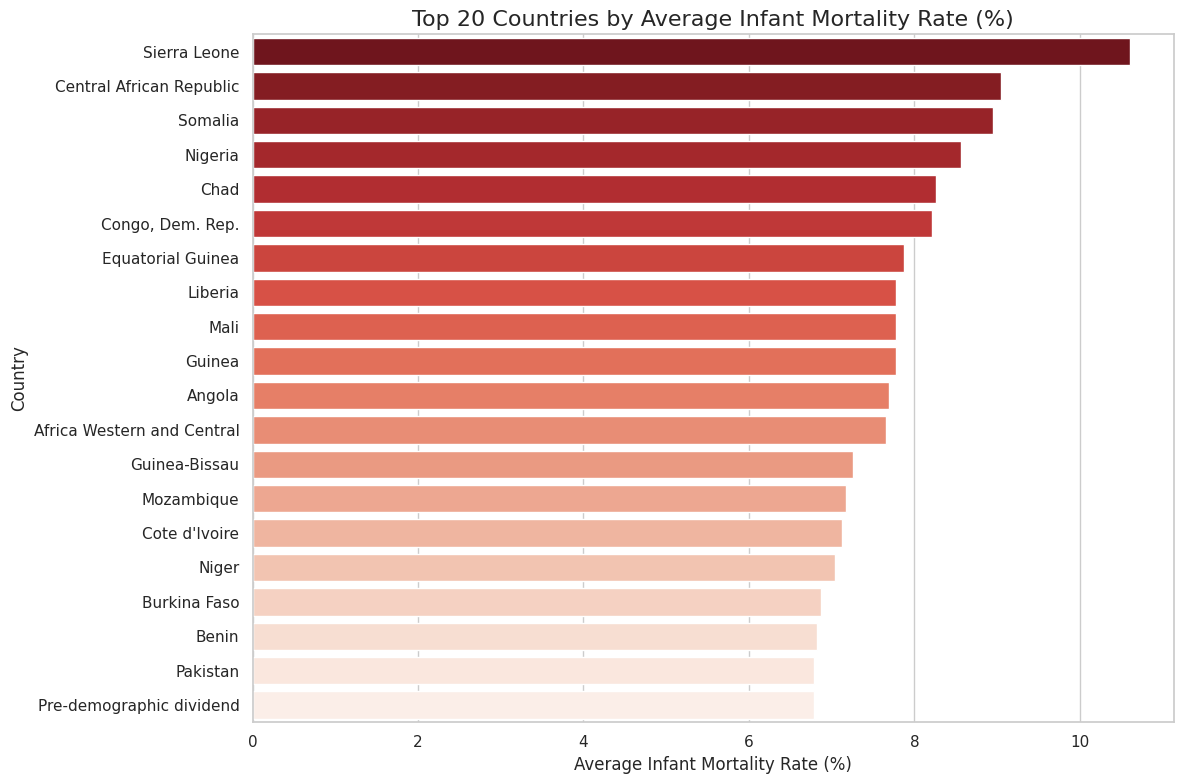

In [ ]:
# Set the plotting style
sns.set(style="whitegrid")

# Group by country and calculate the mean infant mortality rate
top20_mortality = final_df.groupby("Country")["Infant Mortality Rate (%)"].mean().sort_values(ascending=False).head(20)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=top20_mortality.values, y=top20_mortality.index, palette="Reds_r")
plt.title("Top 20 Countries by Average Infant Mortality Rate (%)", fontsize=16)
plt.xlabel("Average Infant Mortality Rate (%)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()


<ipython-input-15-4bf1066c37d3>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lowest_20.values, y=lowest_20.index, palette="Blues_r")


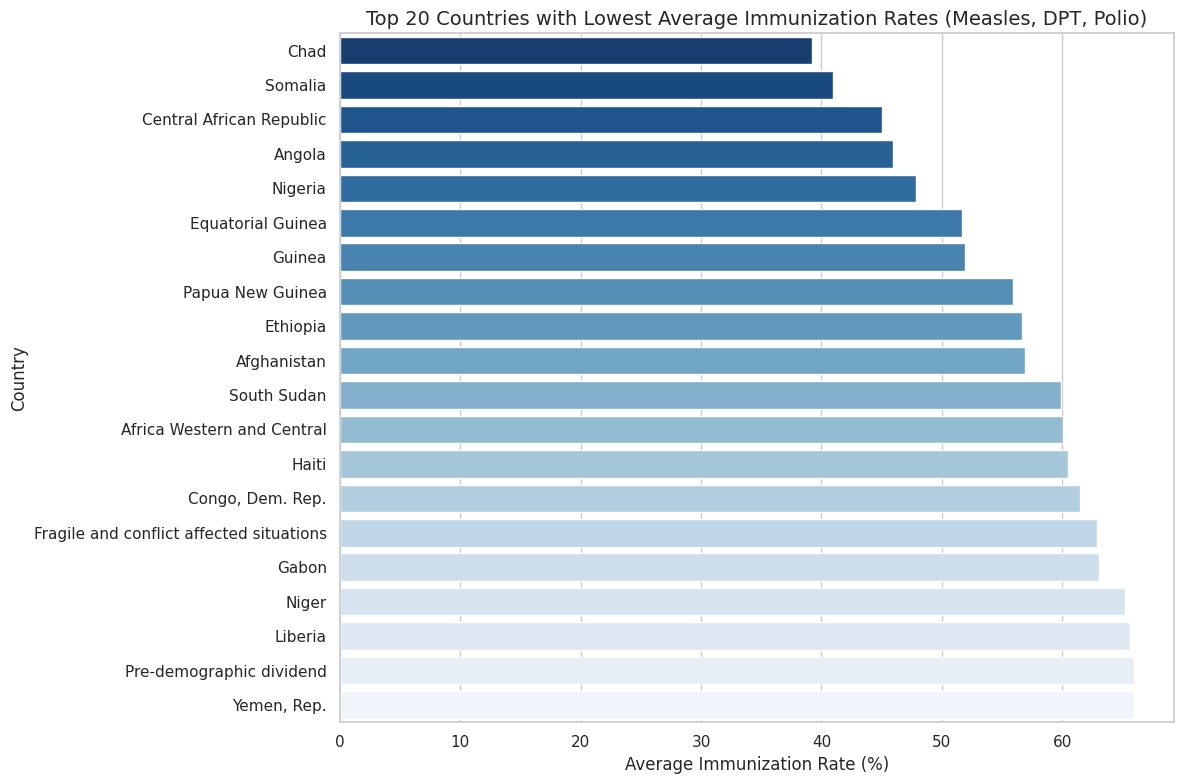

In [ ]:
# Compute average immunization rate across the 3 types
final_df["Average Immunization Rate (%)"] = final_df[
    ["Measles Immunization Rate(%)", "dpt Immunization Rate(%)", "Polio Immunization Rate(%)"]
].mean(axis=1)

# Group by country and compute mean of average immunization rate
lowest_20 = (
    final_df.groupby("Country")["Average Immunization Rate (%)"]
    .mean()
    .sort_values()
    .head(20)
)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=lowest_20.values, y=lowest_20.index, palette="Blues_r")
plt.title("Top 20 Countries with Lowest Average Immunization Rates (Measles, DPT, Polio)", fontsize=14)
plt.xlabel("Average Immunization Rate (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

**Relationship Between Immunization and Mortality Rate**

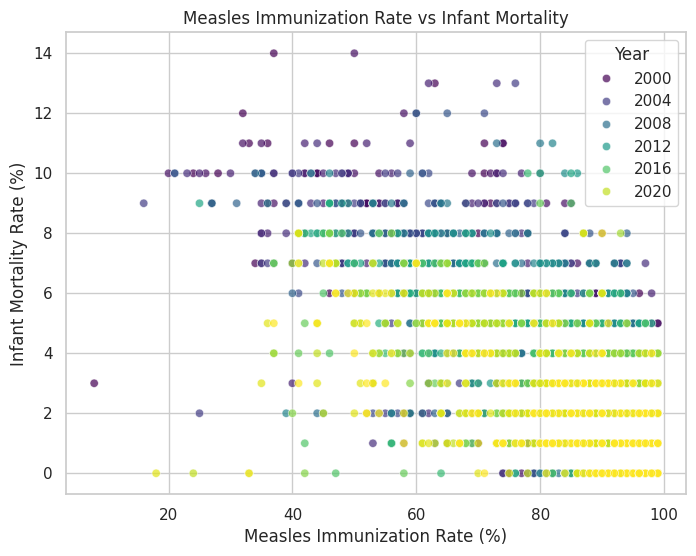

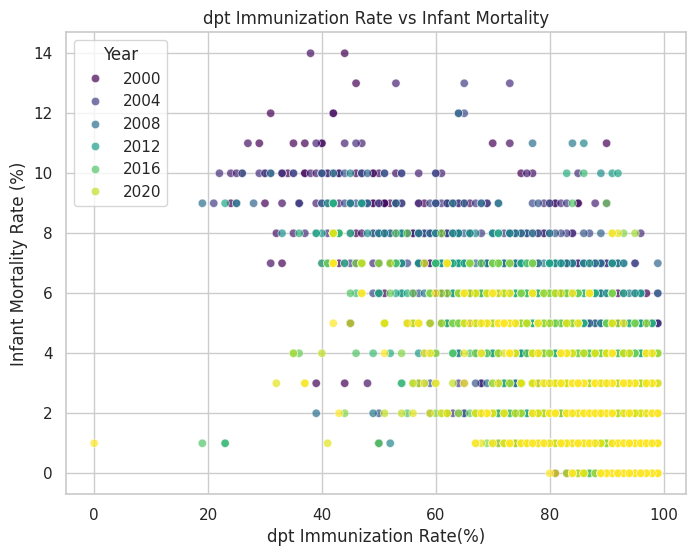

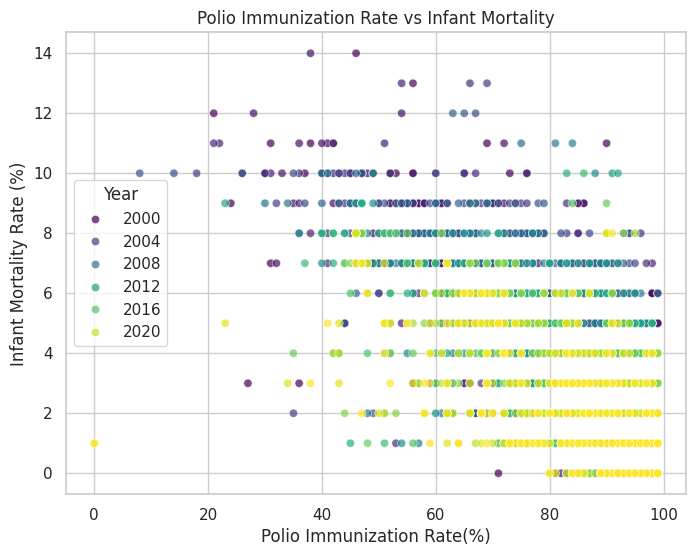

In [ ]:
#Measles plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=final_df,
    x="Measles Immunization Rate(%)",
    y="Infant Mortality Rate (%)",
    hue="Year",
    palette="viridis",
    alpha=0.7
)
plt.title("Measles Immunization Rate vs Infant Mortality")
plt.xlabel("Measles Immunization Rate (%)")
plt.ylabel("Infant Mortality Rate (%)")
plt.grid(True)
plt.show()

# dpt Immunization plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=final_df,
    x="dpt Immunization Rate(%)",
    y="Infant Mortality Rate (%)",
    hue="Year",
    palette="viridis",
    alpha=0.7
)
plt.title("dpt Immunization Rate vs Infant Mortality")
plt.xlabel("dpt Immunization Rate(%)")
plt.ylabel("Infant Mortality Rate (%)")
plt.grid(True)
plt.show()

#Polio plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=final_df,
    x="Polio Immunization Rate(%)",
    y="Infant Mortality Rate (%)",
    hue="Year",
    palette="viridis",
    alpha=0.7
)
plt.title("Polio Immunization Rate vs Infant Mortality")
plt.xlabel("Polio Immunization Rate(%)")
plt.ylabel("Infant Mortality Rate (%)")
plt.grid(True)
plt.show()


# **HOW INSIGHTS FROM AutoML CAN SUPPORT DECISION MAKING IN PUBLIC HEALTH**

**Data-Driven Forecasting**

Ability to accurately forecast infant mortality rates helps public health stakeholders anticipate future healthcare needs, allowing for:

 1. Proactive vaccine supply planning.

 2. Early intervention programs in high-risk regions.

 3. Budget allocation for maternal and child health services.



**Identifying Impactful Interventions**

The model uses DPT, Measles, and Polio immunization rates to predict infant mortality. This directly links vaccination coverage to child survival outcomes, reinforcing:

 1. The effectiveness of immunization programs.

 2. Where to prioritize outreach or vaccination campaigns.



**Regional Targeting**

With a Series Identifier like Country, similar models can be scaled across regions or countries, enabling:

 1. Region-specific policy decisions.

 2. Focused investment in underperforming areas.

**Performance Tracking Over Time**

As new data is added, the model can be retrained to monitor trends in immunization and mortality, supporting:

 1. Longitudinal studies on healthcare progress.

 2. Evaluating the impact of public health interventions over time.

**Supporting Policy with Evidence**

The model provide quantitative evidence to:

 1. Justify health funding and aid programs.

 2. Design policies grounded in empirical trends, not assumptions.